本节结束后您将能够回答的问题
- 向量计算的瓶颈是什么？
- 我可以使用什么工具来查看CPU执行计算的效率？
- 为什么numpy比纯Python更擅长数值计算？
- 什么是缓存未命中和页面错误？
- 如何跟踪代码中的内存分配？

不管你想在计算机上解决什么问题，你总会遇到向量计算。向量计算是计算机工作方式的一部分，也是计算机如何在硅水平上加速程序运行的一部分。计算机唯一知道的是如何对数字进行运算，知道如何同时进行这些计算可以加快程序的速度。

在这一章中，我们试图通过关注一个相对简单的数学问题，解决扩散方程，并理解在CPU级别发生的事情，来揭示这个问题的一些复杂性。通过理解不同的Python代码如何影响CPU以及如何有效地探测这些东西，我们还可以学习如何理解其他问题。

我们将首先介绍这个问题，然后使用纯Python提供一个快速的解决方案。在确定一些内存问题并尝试使用纯Python修复它们之后，我们将介绍numpy并确定它如何以及为什么加快代码的速度。然后，我们将开始做一些算法的改变，并专门化我们的代码来解决手头的问题。通过删除我们正在使用的库的一些通用性，我们将再次能够获得更快的速度。接下来，我们将介绍一些额外的模块，这些模块将有助于在现场简化此类过程，并探讨有关在分析之前进行优化的警告。

最后，我们将看一看Pandas库，它构建在numpy的基础上，获取同质数据列并将它们存储在一个异构类型表中。Pandas已经超越了使用纯numpy类型，现在可以将自己丢失的数据感知类型与numpy数据类型混合使用。虽然Pandas在科学开发人员和数据科学家中非常受欢迎，但关于如何让它快速运行，存在很多错误信息；我们将解决其中一些问题，并为您提供编写高性能和可支持的分析代码的技巧。

# 问题简介

为了在本节中探讨矩阵和向量计算，我们将重复使用流体中扩散的例子。扩散是移动流体并使其均匀混合的机制之一。

在本节中，我们将探讨扩散方程背后的数学。这看起来很复杂，但别担心！我们将迅速简化这一点，使之更易于理解。此外，重要的是要注意，虽然有一个基本的理解，我们正在解决的最终方程将是有用的，而阅读本章，这不是完全必要的；接下来的章节将主要关注代码，而不是公式。不过，了解这些公式将有助于您获得优化代码方法的直觉。一般来说，了解代码背后的动机和复杂的算法将使您对可能的优化方法有更深入的了解。

一个简单的扩散例子是染料在水中的扩散：

如果你在室温下将几滴染料滴入水中，染料会慢慢地向外移动，直到它与水完全混合。由于我们没有搅拌水，也没有足够的温度产生对流，扩散将是混合两种液体的主要过程。当用数值方法求解这些方程时，我们选择我们想要的初始条件的样子，并且能够及时地向前演化初始条件，以查看它在以后的某个时候会是什么样子（见下图).

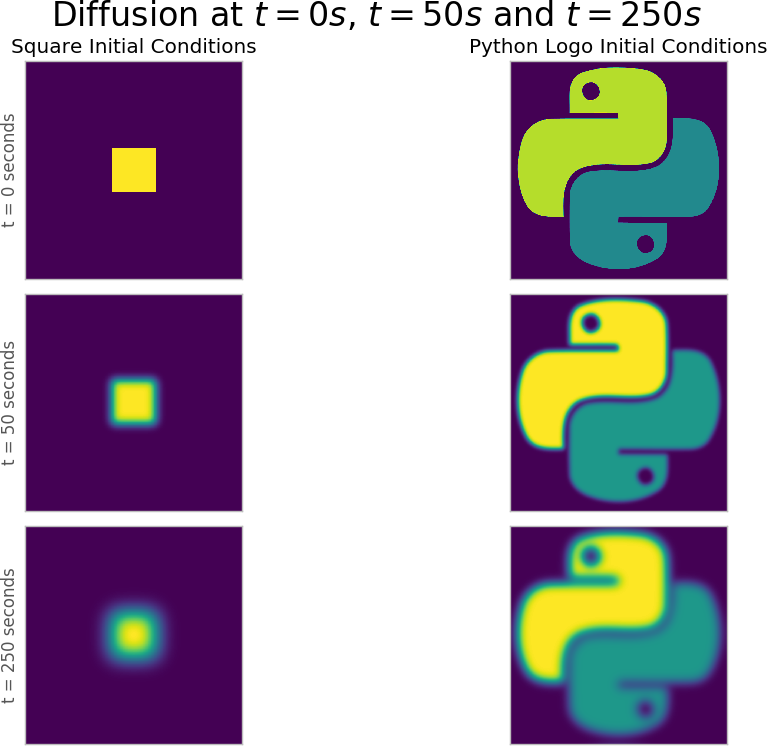

上图，两组初始条件的二维扩散示例

尽管如此，为了我们的目的，了解扩散最重要的事情是它的表述。以一维（1D）的偏微分方程表示，扩散方程如下：

$$\frac{\partial u(x,t)}{\partial x} = D\cdot \frac{\partial^2 u(x,t)}{\partial x^2}$$

在这个公式中，$u$ 是表示我们正在扩散的量的向量。例如，我们可以有一个向量，在只有水的情况下值为0，在只有染料的情况下值为1（在混合的情况下值介于两者之间）。通常，这将是一个二维或三维矩阵，表示流体的实际面积或体积。这样，我们可以让 $u$ 是一个3D矩阵，代表玻璃中的流体，而不是简单地沿着x方向做二阶导数，我们必须把它带到所有的轴上。此外，$D$ 是一个物理值，它表示我们正在模拟的流体的特性。较大的 $D$ 值表示可以非常容易扩散的流体。为简单起见，我们将为代码设置 $D=1$，但仍将其包含在计算中。

我们要做的是取扩散方程，它在空间和时间上是连续的，用离散体积和离散时间来近似它。我们将用欧拉方法来做。欧拉的方法只是简单地把导数写成差分，这样:

$$\frac{\partial u(x,t)}{\partial t} \approx \frac{u(x,t+dt) - u(x,t)}{dt}$$

其中 $dt$ 现在是一个固定数。这个固定的数字表示时间步长，或者我们希望解这个方程的时间分辨率。它可以被认为是我们正在努力制作的电影的帧速率。当帧速率上升（或 $dt$ 下降）时，我们可以更清楚地了解发生了什么。事实上，当 $dt$ 接近零时，欧拉近似变得精确（然而，请注意，这种精确性只能在理论上实现，因为计算机上只有有限的精度，数值误差将很快主导任何结果）。因此，我们可以重写这个方程来计算 $u（x，t+dt）$ ，给定 $u（x，t）$ 。这对我们来说意味着，我们可以从一些初始状态（$u（x，0）$，代表一杯水，就像我们在其中加入一滴染料）开始，通过我们概述的机制搅动，来“进化”这个初始状态，看看它在未来会是什么样子（$u（x，dt）$）。这类问题称为初值问题或柯西问题。利用有限差分近似对 $x$ 的导数进行类似的处理，我们得到了最终的方程：

$$u(x,t+dt) = u(x,t) + dt \ast D  \ast \frac{u(x+dx,t)+u(x-dx,t) - 2\cdot u(x,t)}{dx^2}$$

这里，与 $dt$ 表示帧速率的方式类似，$dx$ 表示图像的分辨率, $dx$ 越小，矩阵中每个单元格表示的区域越小。为简单起见，我们将设置 $D=1$ 和$dx=1$。在进行适当的物理模拟时，这两个值变得非常重要；然而，由于我们求解扩散方程是为了说明问题，它们对我们来说并不重要。

利用这个方程，我们几乎可以解决任何扩散问题。然而，关于这个等式有一些考虑。首先，我们之前说过，$u$ 中的空间索引（即 $x$ 参数）将表示为矩阵中的索引。当 $x$ 在矩阵的开头时，当我们试图找到 $x–dx$ 的值时会发生什么？这个问题叫做边界条件。您可以有固定的边界条件，即“矩阵边界之外的任何值都将被设置为0”（或任何其他值）。或者，您可以使用周期性边界条件来表示值将环绕(也就是说，如果矩阵的某个维度的长度为 $N$ ，则索引 $-1$ 处该维度的值与索引 $N–1$ 处的值相同，而索引 $N$ 处的值与索引 $0$ 处的值相同。换句话说，如果您试图访问索引 $i$ 处的值，您将获得索引（ $i%N$ ）处的值。）

另一个需要考虑的问题是如何存储 $u$。我们可以用一个矩阵来计算每个时间值。至少，我们需要两个矩阵：一个是流体的当前状态，另一个是流体的下一个状态。正如我们将看到的，对于这个特殊的问题有非常激烈的性能考虑。

那么在实践中解决这个问题是什么样的呢？下面包含一些伪代码来说明如何使用我们的方程来解决问题。

一维扩散伪码：

这个代码将获取染料在水中的初始状态，并告诉我们未来每隔0.0001秒系统的样子。结果如下图所示，我们将非常集中的一滴染料（由top-hat函数表示）发展到未来。我们可以看到，在遥远的将来，染料是如何混合得很好的，以至于到处都有类似浓度的染料。

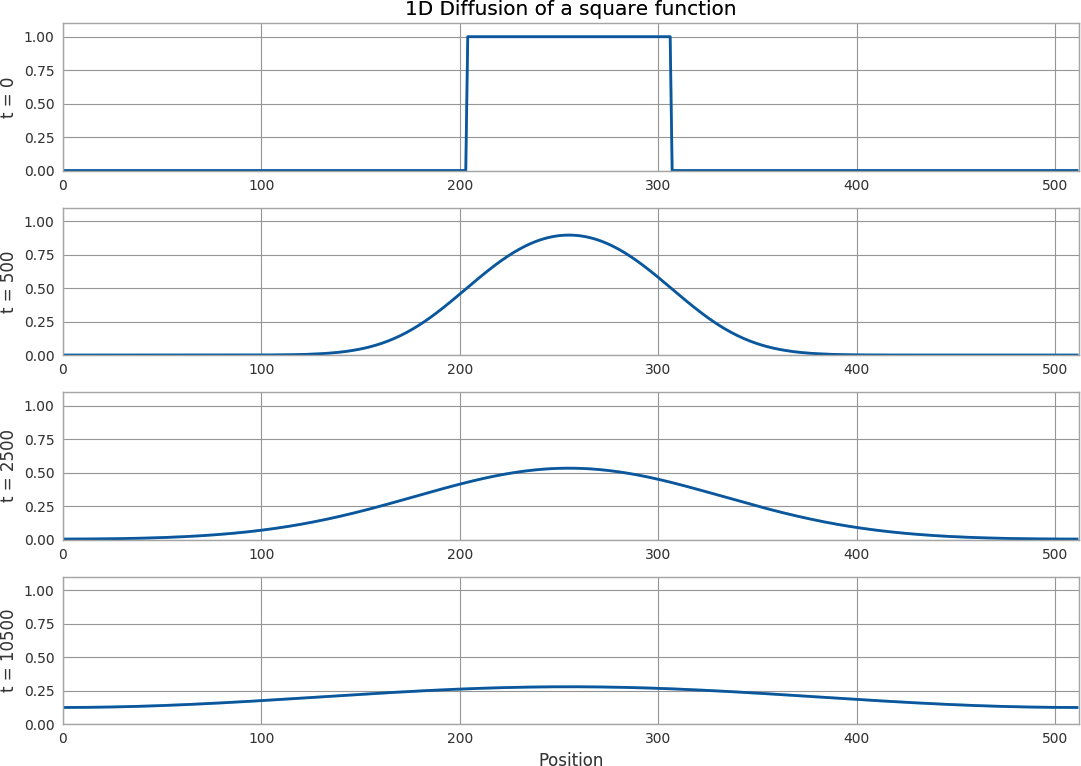

为了本节的目的，我们将求解上述方程的2D版本。所有这一切意味着，我们将在二维矩阵上操作，而不是在向量上操作（或者换言之，一个具有一个索引的矩阵）。方程（以及后续代码）唯一的变化是，我们现在也必须在y方向上取二阶导数。这仅仅意味着我们使用的原始公式变成了：

$$\frac{\partial u(x,y,t) }{\partial t} = D \cdot  (\frac{\partial^2 u(x,y,t)}{\partial x^2} +\frac{\partial^2  u(x,y,t)}{\partial y^2})$$

这个二维数值扩散方程转化为伪代码如下，用我们以前用过的方法。

我们现在可以把所有这些放在一起，编写完整的python 2D扩散代码，作为本章其余部分的基准测试的基础。虽然代码看起来更复杂，但结果类似于一维扩散。

# Python列表还不够好吗？

让我们从示例中获取伪代码 并将其形式化，以便更好地分析其运行时性能。第一步是写出接受矩阵并返回其演化状态的演化函数。

注意

我们可以通过使用 appends 在for循环中构建它，而不是预先分配新的 new_grid 列表。虽然这比我们写的要快得多，但我们得出的结论仍然适用。我们选择这种方法是因为它更具说明性。

全局变量 `grid_shape` 指定我们要模拟的区域有多大；而且，正如“问题简介”中所解释的，我们使用的是周期性边界条件（这就是为什么我们对指数使用模）。要真正使用这段代码，我们必须初始化一个网格并对其调用 evolve。下面示例中的代码是一个非常通用的初始化过程，将在本节中重复使用（它的性能特征将不被分析，因为它必须只运行一次，而 evolve 函数是重复调用的）。

dt 和网格元素的值被选择为足够小，使得算法是稳定的。有关此算法收敛特性的更深入处理，请参见数值公式。

## 分配过多的问题

通过在纯Python进化函数上使用 line_profiler，我们可以开始了解导致运行时可能变慢的原因。查看示例中的探查器输出，我们看到函数中的大部分时间都花在求导计算和更新网格上。这是我们想要的，因为这是一个纯粹的CPU受限问题，任何不花在解决CPU受限问题上的时间都是一个明显的优化地方。

In [ ]:
!kernprof -lv ./diffusion_2d/diffusion_python.py

1. 每次命中都要花费很长时间，因为必须从本地名称空间检索网格形状（有关详细信息，请参阅“字典和名称空间”）。
2. 这一行有320500个与之相关的命中，因为我们操作的网格的xmax=640，并且我们运行了500次函数。计算结果为（640+1）*500，其中额外的一个求值来自循环的终止。
3. 这一行有500个与之相关联的点击，这告诉我们这个函数是在500次运行中被分析的。

有趣的是，我们在第15行中分配了新的网格，在 Per Hit 和 % Time 字段中看到了很大的差异。出现这种差异的原因是，虽然行本身非常慢（每击字段显示每次运行需要0.0495秒，比所有其他行慢得多），但它不像循环中的其他行那样经常被调用。如果我们要减小网格的大小并进行更多的迭代（即，减少循环的迭代次数，但增加调用函数的次数），我们会看到这行的 % Time 增加，并迅速主导运行时。

这是一种浪费，因为无论我们发送什么值来进化， new_grid 的属性都不会改变，new_grid 列表将始终是相同的形状和大小，并且包含相同的值。一个简单的优化就是分配这个列表一次，然后简单地重用它。这样，无论网格大小或迭代次数如何，我们只需要运行一次代码。这种优化类似于将重复代码移出快速循环：

我们可以对扩散代码进行类似的转换，如下面示例所示. 在本例中，我们希望在示例中实例化 new_grid 发送给我们的进化函数。该函数将执行与以前相同的操作：读取网格列表并写入 new_grid 列表。然后我们可以简单地交换 new_grid 和 grid，然后再继续。

减少内存分配后的纯python 2D扩散程序：

我们可以从示例中代码的修改版本的行概要中看到 这个小小的改变使我们的速度提高了31.25%。这使我们得出了一个结论，类似于我们在讨论列表附加操作时得出的结论（参见“列表作为动态数组”）：内存分配并不便宜。每次我们请求内存来存储一个变量或一个列表时，Python都必须花时间与操作系统通信以分配新的空间，然后我们必须迭代新分配的空间以将其初始化为某个值。

只要有可能，重用已经分配的空间将提高性能。但是，在实现这些更改时要小心。虽然加速可以是实质性的，但您应该像往常一样进行概要分析，以确保您正在实现所需的结果，而不是简单地污染您的代码库。

In [ ]:
!kernprof -lv diffusion_python_memory.py

# 内存碎片

我们在上上示例中编写的Python代码仍然存在一个问题，这是使用Python进行这些向量化操作的核心：Python本身并不支持向量化。这有两个原因：Python列表存储指向实际数据的指针，Python字节码没有针对向量化进行优化，因此for循环无法预测何时使用向量化是有益的。

Python列出存储指针的事实意味着，不是实际保存我们关心的数据，而是列出可以在其中找到数据的存储位置。对于大多数应用，这是好的，因为它允许我们在列表中存储我们喜欢的任何类型的数据。然而，当涉及到向量和矩阵运算时，这会导致很多性能下降。

降级是因为每次我们要从网格矩阵中提取一个元素时，都必须进行多次查找。例如，执行 grid[5][2] 要求我们首先对列表网格上的索引5执行列表查找。这将返回指向该位置数据存储位置的指针。然后我们需要对这个返回的对象执行另一个列表查找，查找索引2处的元素。一旦我们有了这个引用，我们就有了实际数据存储的位置。

这种查找的开销不大，在大多数情况下可以忽略不计。但是，如果我们想要的数据位于内存中的一个相邻块中，我们可以在一个操作中移动所有数据，而不是每个元素需要两个操作。这是数据碎片化的一个要点：当数据碎片化时，必须逐个移动每个片段，而不是移动整个块。这意味着您调用了更多的内存传输开销，并且在传输数据时强制CPU等待。我们将通过perf了解在查看缓存未命中时这是多么重要。

在需要时将正确的数据送到CPU的问题与von neumann bottleneck 有关。这是指由于现代计算机使用的分层内存体系结构，内存和CPU之间存在的有限带宽。如果我们可以无限快地移动数据，我们就不需要任何缓存，因为CPU可以立即检索它所需要的任何数据。这将是一种瓶颈不存在的状态。

由于我们不能无限快地移动数据，我们必须从RAM中预取数据，并将其存储在更小但更快的CPU缓存中，这样，当CPU需要一段数据时，它就有希望位于一个可以快速读取的位置。虽然这是一种非常理想化的架构方式，但我们仍然可以看到其中的一些问题我们如何知道未来需要什么样的数据？CPU在分支预测和流水线机制方面做得很好，这些机制试图预测下一条指令，并在处理当前指令的同时将内存的相关部分加载到缓存中。然而，最大限度地减少瓶颈影响的最佳方法是明智地分配内存和计算数据。

探测内存被移动到CPU的情况是相当困难的；然而，在Linux中，perf工具可以用来获得惊人的洞察力，了解CPU是如何处理正在运行的程序的。例如，我们可以在示例中的纯Python代码上运行perf 看看CPU运行代码的效率。

下面算例给出了计算结果。 请注意，本例和下面的perf示例中的输出已被截断，以适合页面的边距。删除的数据包括每个测量值的方差，表示在多个基准中值的变化程度。这有助于了解测量值在多大程度上取决于程序的实际性能特性，而不是其他系统属性，例如使用系统资源的其他正在运行的程序。

例：纯Python 2D扩散的性能计数器，内存分配减少（网格大小：640）× 640500次迭代）

## 了解性能

让我们花一点时间来了解perf提供给我们的各种性能指标以及它们与代码的关系。任务时钟度量告诉我们任务的时钟周期。这与总运行时不同，因为如果我们的程序运行一秒钟，但使用了两个CPU，那么任务时钟将为2000（任务时钟通常以毫秒为单位）。方便的是，perf为我们计算并告诉我们，在这个度量旁边，使用了多少个CPUu（这里写着“XXXX个CPU已使用”）。即使使用两个CPU，这个数字也不会正好是2，因为进程有时依赖于其他子系统为其执行指令（例如，分配内存时）。

另一方面，指令告诉我们代码发出了多少CPU指令，而cycles告诉我们运行所有这些指令需要多少CPU周期。这两个数字之间的差异表明我们的代码在向量化和管道化方面做得有多好。通过流水线，CPU可以在获取和准备下一个操作的同时运行当前操作。

cs（表示“上下文切换”）和CPU迁移告诉我们程序是如何暂停的，以便等待内核操作完成（如I/O）、让其他应用程序运行或将执行移到另一个CPU内核。当发生上下文切换时，程序的执行将停止，而另一个程序将被允许运行。这是一项非常耗时的任务，我们希望尽可能地将其最小化，但我们无法控制何时发生这种情况。当程序被允许关闭时，内核代理；但是，我们可以采取措施阻止内核移动我们的程序。通常，内核在执行I/O（例如从内存、磁盘或网络中读取）时会挂起程序。正如您将在后面的章节中看到的，我们可以使用异步例程来确保我们的程序即使在等待I/O时也仍然使用CPU，这将允许我们在不切换上下文的情况下继续运行。此外，我们可以设置程序的nice值来赋予程序优先级，并阻止内核进行上下文切换。类似地，当程序在与以前不同的CPU上停止和恢复时，会发生CPU迁移，以使所有CPU具有相同的利用率。这可以看作是一个特别糟糕的上下文切换，因为我们的程序不仅暂时停止，而且还会丢失一级缓存中的所有数据（回想一下，每个CPU都有自己的一级缓存）。

页面错误（或仅仅是错误）是现代Unix内存分配方案的一部分。当分配内存时，内核除了给程序一个对内存的引用之外，并没有做什么。然而，稍后，当内存第一次被使用时，操作系统抛出一个小的页面错误中断，它会暂停正在运行的程序并正确地分配内存。这就是所谓的延迟分配系统。虽然这种方法是对以前的内存分配系统的优化，但是较小的页错误是一个非常昂贵的操作，因为大多数操作都是在正在运行的程序的范围之外完成的。还有一个主要的页面错误，当程序从尚未读取的设备（磁盘、网络等）请求数据时会发生。这些操作成本更高：它们不仅会中断程序，而且还涉及从数据所在的设备读取数据。这种页面错误通常不会影响CPU工作；然而，对于任何进行磁盘或网络读写的程序来说，这都是一个痛苦的根源

一旦我们在内存中有了数据并引用了它，数据就会通过不同的内存层（L1/L2/L3内存请参阅“通信层”了解对此的讨论）。每当我们引用缓存中的数据时，缓存引用度量就会增加。如果缓存中还没有这些数据，并且需要从RAM中获取这些数据，这将被视为缓存未命中。如果我们正在读取最近读取的数据（该数据仍在缓存中）或位于最近读取的数据附近的数据（数据以块的形式从RAM发送到缓存中），则不会出现缓存未命中。当涉及到CPU工作时，缓存未命中可能是一个慢化的来源，因为我们需要等待从RAM获取数据，并且中断了执行管道的流（稍后将详细介绍）。因此，按顺序读取一个数组将给出许多缓存引用，但不会有太多缓存未命中，因为如果读取元素i，元素i+1将已经在缓存中。然而，如果我们随机读取一个数组，或者没有在内存中很好地布局数据，那么每次读取都需要访问不可能已经在缓存中的数据。在本章后面，我们将讨论如何通过优化内存中的数据布局来减少这种影响。

分支是代码中执行流更改的时间。考虑一个if…then语句，根据条件语句的结果，我们将执行一段或另一段代码。这本质上是代码执行中的一个分支程序中的下一条指令可以是以下两种情况之一。为了优化这一点，特别是在管道方面，CPU尝试猜测分支将采用哪个方向，并预加载相关指令。当这个预测不正确时，我们将得到一个分支未命中。分支未命中可能会非常混乱，并可能导致许多奇怪的效果（例如，某些循环在排序列表上的运行速度会比在未排序列表上的运行速度快得多，因为分支未命中的次数会更少）

perf可以跟踪更多的指标，其中许多指标非常特定于运行代码的CPU。您可以运行perf list来获取系统上当前支持的度量的列表。例如，在本书的上一版中，我们在一台同时支持stalled cycles frontend和stalled cycles backend的机器上运行，它告诉我们程序等待管道前端或后端填充的周期数。这可能是由于缓存未命中、分支预测失误或资源冲突造成的。管道的前端负责从内存中提取下一条指令并将其解码为有效的操作，而后端负责实际运行该操作。这些指标有助于根据特定CPU的优化和架构选择来调整代码的性能；然而，除非您总是在同一个芯片组上运行，否则过分担心它们可能是过分的。

## 利用perf的输出做出决策

考虑到所有这些，示例中的性能指标告诉我们，在运行代码时，CPU必须引用一级/二级缓存656345027次。在这些参考文献中，有349562390（或53.3%）是对当时不在内存中且必须检索的数据的请求。此外，我们可以看到，在每个CPU周期中，我们能够执行平均2.91条指令，这告诉我们流水线、无序执行和超线程（或任何其他CPU特性，允许您在每个时钟周期运行多条指令）带来的总速度提升。

碎片会增加到CPU的内存传输次数。此外，由于请求计算时CPU缓存中没有准备好多个数据段，因此无法对计算进行矢量化。正如在“通信层”中所解释的，计算的矢量化（或者让CPU一次进行多个计算）只有在我们能够用所有相关数据填充CPU缓存时才能发生。因为总线只能移动连续的内存块，所以只有当网格数据顺序存储在RAM中时才有可能。由于列表存储指向数据的指针而不是实际数据，因此网格中的实际值分散在内存中，不能一次复制所有值。

我们可以通过使用数组模块而不是列表来缓解这个问题。这些对象在内存中按顺序存储数据，因此数组的一个片实际上表示内存中的一个连续范围。然而，这并不能完全解决这个问题，因为现在我们有顺序存储在内存中的数据，但是Python仍然不知道如何对循环进行矢量化。我们所希望的是，任何一次对数组中的一个元素进行算术运算的循环都可以处理数据块，但正如前面提到的，Python中没有这样的字节码优化（部分原因是该语言的动态特性）。

此外，由于实现细节的原因，在创建必须迭代的数据列表时使用数组类型实际上比简单地创建列表要慢。这是因为array对象存储它存储的数字的一个非常低级的表示，在返回给用户之前，必须将其转换为与Python兼容的版本。每次索引数组类型时，都会产生额外的开销。这个实现决策使得数组对象不太适合数学，而更适合在内存中更有效地存储固定类型的数据。

## 输入numpy

In [ ]:
from array import array
import numpy


def norm_square_list(vector):
    """
    >>> vector = list(range(1_000_000))
    >>> %timeit norm_square_list(vector)
    85.5 ms ± 1.65 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
    """
    norm = 0
    for v in vector:
        norm += v * v
    return norm


def norm_square_list_comprehension(vector):
    """
    >>> vector = list(range(1_000_000))
    >>> %timeit norm_square_list_comprehension(vector)
    80.3 ms ± 1.37 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
    """

    return sum([v * v for v in vector]) 


def norm_square_array(vector):
    """
    >>> vector_array = array('l', range(1_000_000))
    >>> %timeit norm_square_array(vector_array)
    101 ms ± 4.69 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
    """
    norm = 0
    for v in vector:
        norm += v * v
    return norm


def norm_square_numpy(vector):
    """
    >>> vector_np = numpy.arange(1_000_000)
    >>> %timeit norm_square_numpy(vector_np)
    3.22 ms ± 136 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
    """
    
        '''
    这将在向量上创建两个隐含循环，
    一个用于乘法，另一个用于求和。
    这些循环类似于norm_square_list_comprehension中的循环，但它们是使用numpy的优化数值代码执行的。
    '''
    return numpy.sum(vector * vector)  


def norm_square_numpy_dot(vector):
    """
    >>> vector_np = numpy.arange(1_000_000)
    >>> %timeit norm_square_numpy_dot(vector_np)
    960 µs ± 41.1 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
    """
    '''
    这是使用矢量化的numpy.dot操作在numpy中执行向量规范的首选方法。
    效率较低的 norm_square_numpy 代码用于说明。
    '''
    return numpy.dot(vector, vector)

更简单的numpy代码运行89× 比标准方格和83.65快× 比“优化的”Python列表理解更快。纯Python循环方法和列表理解方法在速度上的差异显示了在幕后进行更多计算的好处，而不是在Python代码中显式地进行计算。通过使用Python已经构建的机器执行计算，我们可以获得构建Python的本机C代码的速度。这在一定程度上也是numpy代码中为什么会有如此大的加速的原因：我们没有使用广义列表结构，而是有一个经过微调和专门构建的对象来处理数字数组。
除了更加轻量级和专业化的机器之外，numpy对象还为我们提供了内存局部性和矢量化操作，这在处理数值计算时非常重要。CPU的速度非常快，大多数情况下，简单地获取所需的数据是快速优化代码的最佳方法。使用前面介绍的perf工具运行每个函数可以看到，array和纯Python函数需要大约1012条指令，而numpy版本需要大约109条指令。此外，array和纯Python版本的缓存未命中率约为53%，而numpy版本的缓存未命中率约为20%。

在我们的norm_square_numpy代码中，当执行 `vector*vector` 时，numpy将处理一个隐含的循环。隐含循环与我们在其他示例中显式写出的循环相同：在vector中的所有项上循环，将每个项乘以自身。但是，由于我们告诉numpy这样做，而不是显式地用Python代码编写，因此numpy可以利用它想要的所有优化。在后台，numpy有非常优化的C代码，专门用来利用CPU启用的任何矢量化。此外，numpy数组在内存中按顺序表示为低级数值类型，这使它们具有与数组对象相同的空间要求（来自array模块）。

作为额外的好处，我们可以将这个问题重新表述为一个点积，numpy支持这个点积。这给了我们一个单一的运算来计算我们想要的值，而不是先取两个向量的乘积然后求和。如下图所示，这个运算，norm_numpy_dot，比其他的运算好很多，这要归功于函数的特殊化，因为我们不需要像 norm_numpy 那样存储`vector*vector`的中间值。

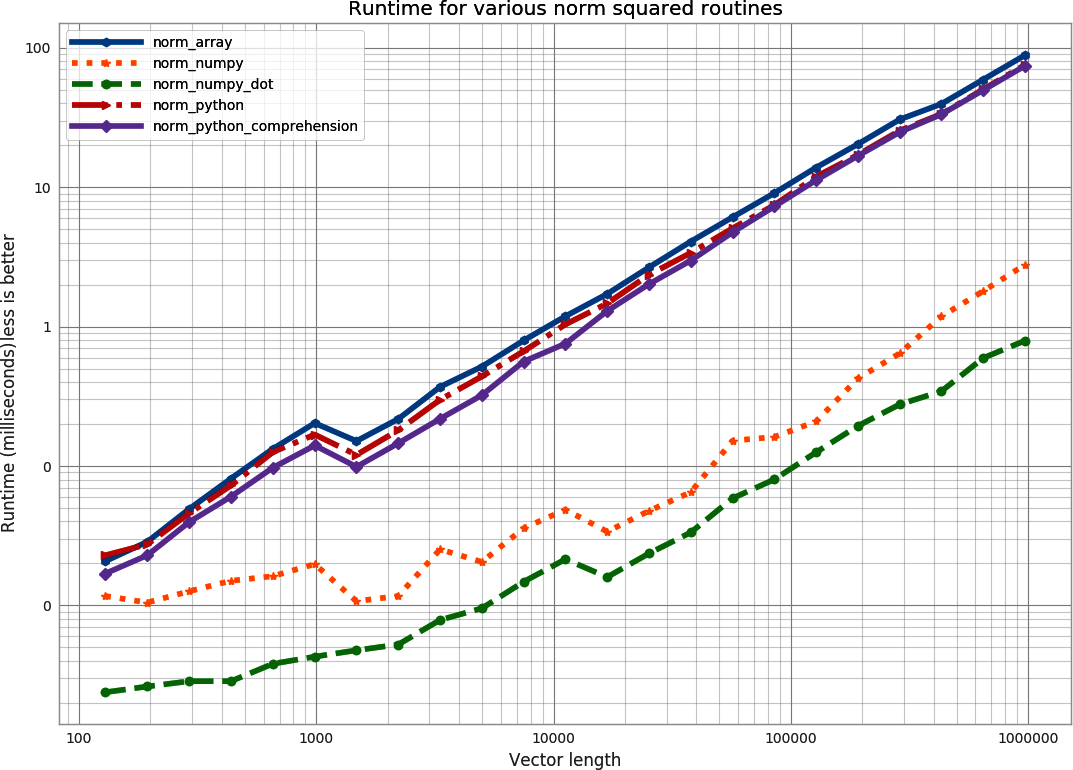

运行时具有不同长度向量的各种范数平方示例

# numpy在扩散问题中的应用

利用我们对numpy的了解，我们可以很容易地将纯Python代码调整为向量化。我们必须引入的唯一新功能是numpy的roll函数。这个函数的作用与我们的模索引技巧相同，但它对整个numpy数组也是如此。本质上，它将这种重新索引矢量化：

In [1]:
import numpy as np
np.roll([1,2,3,4], 1)

array([4, 1, 2, 3])

In [2]:
np.roll([[1,2,3],[4,5,6]], 1, axis=1)

array([[3, 1, 2],
       [6, 4, 5]])

roll函数创建了一个新的numpy数组，它可以被认为是好的也可以是坏的。缺点是我们需要时间来分配新的空间，然后需要用适当的数据填充这些空间。另一方面，一旦我们创建了这个新的滚动数组，我们就可以很快地对它进行矢量化操作，而不会因为CPU缓存而丢失缓存。这会严重影响我们必须在网格上进行的实际计算的速度。在本章后面我们将重写它，这样我们就可以在不需要不断分配更多内存的情况下获得同样的好处。

通过这个附加函数，我们可以重写示例中的Python扩散代码使用更简单的矢量化numpy数组。下面显示了我们最初的numpy扩散代码。

In [3]:
from numpy import (zeros, roll)

grid_shape = (640, 640)


def laplacian(grid):
    return (
        roll(grid, +1, 0) +
        roll(grid, -1, 0) +
        roll(grid, +1, 1) +
        roll(grid, -1, 1) -
        4 * grid
    )


def evolve(grid, dt, D=1):
    return grid + dt * D * laplacian(grid)


def run_experiment(num_iterations):
    grid = zeros(grid_shape)

    block_low = int(grid_shape[0] * 0.4)
    block_high = int(grid_shape[0] * 0.5)
    grid[block_low:block_high, block_low:block_high] = 0.005

    start = time.time()
    for i in range(num_iterations):
        grid = evolve(grid, 0.1)
    return time.time() - start

我们马上看到这个代码要短得多。这有时是一个很好的性能指标：我们在Python解释器之外做了很多繁重的工作，希望在一个专门为性能和解决特定问题而构建的模块中（但是，这应该始终经过测试！）。这里的一个假设是numpy使用更好的内存管理来更快地为CPU提供所需的数据。然而，由于这种情况是否发生取决于numpy的实际实现，让我们分析一下我们的代码，看看我们的假设是否正确。

numpy 2D扩散的性能计数器（网格大小：640）× 640500次迭代）

这表明对numpy的简单修改给了我们63.3分× 通过减少内存分配来加速纯Python实现. 这是如何实现的？

首先，我们要感谢numpy提供的矢量化。尽管numpy版本似乎每个周期运行的指令更少，但每条指令都要做更多的工作。也就是说，一条矢量化指令可以将一个数组中的四个（或更多）数字相乘，而不需要四条独立的乘法指令。总的来说，这会减少解决同一问题所需的全部指令。

其他几个因素导致numpy版本需要较低的指令绝对数来解决扩散问题。其中之一与运行纯Python版本时可用的完整pythonapi有关，但不一定是对于numpy版本，例如，纯Python网格可以在纯Python中附加，但不能在numpy中附加。尽管我们没有显式地使用这个（或其他）功能，但是在提供一个可以使用它的系统时会有开销。由于numpy可以假设存储的数据总是数字，因此可以针对数字上的操作对数组的所有内容进行优化。当我们谈论Cython（参见“Cython”）时，我们将继续删除有利于性能的必要功能，在Cython中甚至可以删除列表边界检查来加速列表查找。

通常情况下，指令的数量不一定与性能相关。指令较少的程序可能无法有效地发出指令，或者它们可能是慢指令。然而，我们看到，除了减少指令数量之外，numpy版本还降低了一个很大的低效率：缓存未命中（缓存未命中率为20.8%，而不是53.3%）。如“内存碎片”中所述，缓存未命中会降低计算速度，因为CPU必须等待从较慢的内存中检索数据，而不是让数据立即在其缓存中可用。事实上，内存碎片是影响性能的一个主要因素，如果我们在numpy中禁用矢量化，但保持其他所有内容不变，与纯Python版本相比，我们仍然可以看到相当大的速度提高：

这表明我们的63.3× 引入numpy时的加速不是矢量化的指令集，而是内存局部性和减少的内存碎片。事实上，我们可以从前面的实验中看到，矢量化只占63.3%左右× 加速。

意识到内存问题是减慢代码速度的主要因素，这并没有带来太大的冲击。计算机设计得非常好，可以精确地完成我们要求他们做的计算，把数字相乘和相加。瓶颈在于让这些数字足够快地传送到CPU上，让它尽可能快地完成计算。

## 内存分配和 In-Place 操作

为了优化以记忆为主的效果，让我们尝试使用我们在示例中使用的相同方法 6-6来减少我们在numpy代码中的分配数量。分配比我们前面讨论的缓存未命中要糟糕得多。当在缓存中找不到正确的数据时，分配也必须向操作系统请求可用的数据块，然后保留它，而不是简单地在RAM中找到正确的数据。对操作系统的请求产生的开销比简单地填充缓存要大得多，而填充缓存未命中是在主板上优化的硬件例程，分配内存需要与另一个进程（内核）对话才能完成。

删除示例中的分配 6-9，我们将在代码开头预先分配一些暂存空间，然后只使用就地操作。就地操作（例如`+=，*=`，等等）重用其中一个输入作为其输出。这意味着我们不需要分配空间来存储计算结果。

为了显式地展示这一点，我们将研究在对numpy数组执行操作时numpy数组的id是如何变化的. 对于numpy数组，id是一种很好的跟踪方法，因为id指示引用的是内存的哪个部分。如果两个numpy数组具有相同的id，则它们引用的是内存的同一部分。

减少内存分配的 In-Place 操作:

In [4]:
import numpy as np

array1 = np.random.random((10,10))
array2 = np.random.random((10,10))

id(array1)

84903216

In [5]:
array1 += array2
id(array1)

84903216

这两个ID是相同的，因为我们正在执行就地操作。这意味着array1的内存地址不变；我们只是在改变其中包含的数据。

In [6]:
array1 = array1 + array2
id(array1)

84751344

这里，内存地址已更改。在执行array1+array2时，将分配一个新的内存地址，并用计算结果填充该地址。但是，这确实有好处，因为当需要保留原始数据时（即，array3=array1+array2允许您继续使用array1和array2，而就地操作会销毁一些原始数据）。

此外，我们可以看到非就地操作的预期放缓。在示例中，我们看到使用就地操作可以为100个数组提供27%的加速× 100个元素。由于内存分配变得更加繁重，随着阵列的增长，这个余量将变得更大。但是，需要注意的是，只有当数组大小大于CPU缓存时，才会发生这种效果！当数组更小，并且两个输入和输出都可以放入缓存时，异地操作会更快，因为它可以受益于矢量化。

In-Place 和 out-of-place 操作之间的运行时差异:

In [7]:
import numpy as np

In [8]:
%%timeit array1, array2 = np.random.random((2, 100, 100)) 
array1 = array1 + array2

The slowest run took 5.67 times longer than the fastest. This could mean that an intermediate result is being cached 
100000 loops, best of 5: 8.86 µs per loop


这些数组太大，无法放入CPU缓存，而且由于分配和缓存未命中较少，就地操作速度更快。请注意，我们使用%%timeit而不是%timeit，这允许我们指定代码来设置没有计时的实验。

以下这些数组太大，无法放入CPU缓存，而且由于分配和缓存未命中较少，就地操作速度更快。

In [9]:
%%timeit array1, array2 = np.random.random((2, 100, 100))
array1 += array2

The slowest run took 4.99 times longer than the fastest. This could mean that an intermediate result is being cached 
100000 loops, best of 5: 7.24 µs per loop


In [10]:
%%timeit array1, array2 = np.random.random((2, 5, 5))
array1 += array2

The slowest run took 10.59 times longer than the fastest. This could mean that an intermediate result is being cached 
1000000 loops, best of 5: 1.64 µs per loop


缺点是在重写示例代码时使用就地操作不是很复杂，它确实会使生成的代码更难阅读。在示例中，我们可以看到重构的结果。我们实例化网格和下一个网格向量，并不断地相互交换它们。网格是我们知道的关于系统的当前信息，在运行evolve之后，下一个网格包含更新的信息。

使大多数 numpy in-place 操作：

In [12]:
def laplacian(grid, out):
    np.copyto(out, grid)
    out *= -4
    out += np.roll(grid, +1, 0)
    out += np.roll(grid, -1, 0)
    out += np.roll(grid, +1, 1)
    out += np.roll(grid, -1, 1)


def evolve(grid, dt, out, D=1):
    laplacian(grid, out)
    out *= D * dt
    out += grid


def run_experiment(num_iterations):
    next_grid = np.zeros(grid_shape)
    grid = np.zeros(grid_shape)

    block_low = int(grid_shape[0] * 0.4)
    block_high = int(grid_shape[0] * 0.5)
    grid[block_low:block_high, block_low:block_high] = 0.005

    start = time.time()
    for i in range(num_iterations):
        evolve(grid, 0.1, next_grid)
        '''
        由于evolve的输出存储在下一个网格的输出向量中，因此我们必须交换这两个变量，
        以便在循环的下一次迭代中，网格具有最新的信息。这种交换操作非常便宜，
        因为只更改对数据的引用，而不更改数据本身。
        '''
        grid, next_grid = next_grid, grid  
    return time.time() - start

警告

记住这一点很重要，因为我们希望每个操作都到位，所以每当我们做向量操作时，我们必须把它放在自己的行上。这会使像 $A=A*B+C$ 这样简单的事情变得非常复杂。由于Python非常强调可读性，因此我们应该确保我们所做的更改能够为我们提供足够的加速。

比较下面示例中的性能指标，我们发现去除虚假的分配将代码的速度提高了30.9%。这种加速部分来自于缓存未命中数的减少，但主要来自于小故障的减少。这来自于通过重用已经分配的空间来减少代码中所需的内存分配数量。

当程序访问内存中新分配的空间时，会导致小错误。由于内存地址是由内核延迟分配的，当您第一次访问新分配的数据时，内核会暂停执行，同时确保所需的空间存在，并创建对它的引用供程序使用。这种增加的机器运行起来相当昂贵，而且会大大降低程序的速度。除了那些需要运行的额外操作之外，我们还丢失了缓存中的任何状态以及执行指令流水线的任何可能性。本质上，我们必须放弃我们正在做的一切，包括所有相关的优化，以便出去分配一些内存。

具有 in-place 内存操作的numpy的性能指标（网格大小：640）× 640500次迭代）：

## 选择性优化：找到需要修复的内容

查看示例中的代码，似乎我们已经解决了手头的大部分问题：我们通过使用numpy减少了CPU负担，并且减少了解决问题所需的分配数量。然而，总有更多的调查要做。如果我们在代码上做一个行配置文件，我们看到我们的大部分工作是在拉普拉斯函数中完成的。事实上，进化运行所需的84%的时间都花在拉普拉斯上。

Line profiling 显示拉普拉斯算法花费了太多的时间

拉普拉斯语速如此之慢可能有很多原因。然而，有两个主要的高层次问题需要考虑。首先，看起来对np.roll的调用正在分配新的向量（我们可以通过查看函数的文档来验证这一点）。这意味着，即使我们在之前的重构中删除了七个内存分配，仍然有四个未完成的分配。此外，np.roll是一个非常通用的函数，它有很多代码来处理特殊情况。因为我们确切地知道我们要做什么（只将第一列数据移动到每个维度的最后一列），所以我们可以重写这个函数来消除大多数虚假代码。我们甚至可以将np.roll逻辑与发生在roll数据上的add操作合并，以生成一个非常专门的roll_add函数，它以最少的分配数量和最少的额外逻辑实现我们想要的功能。

下面展示了重构的样子。我们所要做的就是创建新的roll_add函数并让拉普拉斯使用它。因为numpy支持花哨的索引，所以实现这样一个函数只是不把索引弄乱的问题。然而，如前所述，虽然此代码的性能可能更高，但可读性要差得多。

创建我们自己的 roll 函数：

In [13]:
import numpy as np


def roll_add(rollee, shift, axis, out):
    """
    Given a matrix, a rollee, and an output matrix, out, this function will
    perform the calculation:

        >>> out += np.roll(rollee, shift, axis=axis)

    This is done with the following assumptions:
        * rollee is 2D
        * shift will only ever be +1 or -1
        * axis will only ever be 0 or 1 (also implied by the first assumption)

    Using these assumptions, we are able to speed up this function by avoiding
    extra machinery that numpy uses to generalize the roll function and also
    by making this operation intrinsically in-place.
    """
    if shift == 1 and axis == 0:
        out[1:, :] += rollee[:-1, :]
        out[0, :] += rollee[-1, :]
    elif shift == -1 and axis == 0:
        out[:-1, :] += rollee[1:, :]
        out[-1, :] += rollee[0, :]
    elif shift == 1 and axis == 1:
        out[:, 1:] += rollee[:, :-1]
        out[:, 0] += rollee[:, -1]
    elif shift == -1 and axis == 1:
        out[:, :-1] += rollee[:, 1:]
        out[:, -1] += rollee[:, 0]


def test_roll_add():
    rollee = np.asarray([[1, 2], [3, 4]])
    for shift in (-1, +1):
        for axis in (0, 1):
            out = np.asarray([[6, 3], [9, 2]])
            expected_result = np.roll(rollee, shift, axis=axis) + out
            roll_add(rollee, shift, axis, out)
            assert np.all(expected_result == out)


def laplacian(grid, out):
    np.copyto(out, grid)
    out *= -4
    roll_add(grid, +1, 0, out)
    roll_add(grid, -1, 0, out)
    roll_add(grid, +1, 1, out)
    roll_add(grid, -1, 1, out)

如果我们看一下示例中的性能计数器，对于这个重写，我们看到虽然它快22% ，大部分都差不多。主要的区别还是缓存未命中，下降了7%×. 这一变化似乎也影响了到CPU的指令吞吐量，将每个周期的指令数从0.85增加到0.99（增加14%）。同样，故障率下降了12.85%。这似乎是一个结果，首先做辊到位，以及减少数量的numpy机械，需要在适当的地方做所有我们想要的计算。我们不是首先滚动数组，而是执行numpy要求的其他计算，以便执行边界检查和错误处理，然后添加结果，而是一次性完成所有操作，而不是每次都要求计算机重新填充缓存。

具有in-place内存操作和自定义拉普拉斯函数的numpy的性能指标（网格大小：640）× 640500次迭代）：

# numexpr：使 in-place 操作更快更容易

numpy优化向量运算的一个缺点是每次只对一个操作进行优化。也就是说，当我们用numpy向量执行操作A×B+C时，首先整个A×B操作完成，并且数据存储在临时向量中；然后这个新向量加上C。示例中扩散代码的就地版本 6-14非常明确地表明了这一点。

但是，许多模块可以帮助实现这一点。numexpr是一个模块，它可以获取整个向量表达式，并将其编译为非常高效的代码，该代码经过优化以最小化缓存未命中和使用的临时空间。此外，表达式可以使用多个CPU核并利用CPU可能支持的专用指令，以获得更大的加速。它甚至支持OpenMP，它可以在您的机器上跨多个内核并行执行操作。

更改代码以使用numexpr非常容易：所需的只是将表达式重写为带局部变量引用的字符串。表达式在幕后编译（并缓存，以便对同一表达式的调用不会产生相同的编译成本），并使用优化的代码运行。例子展示了将evolve函数更改为使用numexpr的简单性。在本例中，我们选择使用evaluate函数的out参数，这样numexpr就不会分配一个新的向量来返回计算结果。

使用numexpr进一步优化大型矩阵运算：

In [14]:
from numexpr import evaluate

def evolve(grid, dt, next_grid, D=1):
    laplacian(grid, next_grid)
    evaluate("next_grid * D * dt + grid", out=next_grid)

numexpr的一个重要特性是它考虑了CPU缓存。它专门移动数据，以便各个CPU缓存都有正确的数据，从而最大限度地减少缓存未命中。当我们对更新的代码运行perf时，我们看到了加速。但是，如果我们看一个较小的256× 256格，我们看到速度下降. 为什么会这样？

具有 in-place 内存操作、自定义拉普拉斯函数和numexpr（网格大小：640）的numpy的性能指标× 640500次迭代）：

我们用numexpr在程序中引入的许多额外机制都涉及缓存方面的考虑。当我们的网格大小很小，并且计算所需的所有数据都放在缓存中时，这个额外的机器只会添加更多对性能没有帮助的指令。此外，编译我们编码为字符串的向量操作会增加很大的开销。当程序的总运行时很小时，这种开销会非常明显。但是，随着网格大小的增加，我们应该看到numexpr比原生numpy更好地利用我们的缓存。此外，numexpr使用多个核来进行计算，并尝试饱和每个核的缓存。当网格的大小很小时，管理多核的额外开销会压倒任何可能的速度增长。

我们正在运行代码的特定计算机具有8192 KB的缓存（Intel Core i7-7820HQ）。因为我们在两个数组上操作，一个用于输入，一个用于输出，所以我们可以很容易地计算将填充缓存的网格大小。我们可以存储的网格元素总数为8192KB/64位=1024000。因为我们有两个网格，所以这个数字被分成两个对象（因此每个对象最多可以是1024000/2=512000个元素）。最后，取这个数的平方根，我们就得到了使用那么多网格元素的网格的大小。总之，这意味着大约有两个大小为715的二维阵列× 715将填满缓存（）。然而，实际上，我们自己不需要填充缓存（其他程序会填充部分缓存），所以实际上我们可能可以容纳两个640× 640个阵列。我们可以看到当网格大小从512跳跃时× 512至1024× 1024，numexpr代码的性能开始优于纯numpy。

# 一个警示故事：验证“优化”（scipy）

从这一节中我们要学到的一件重要的事情是我们对每一个优化所采用的方法：分析代码以了解正在发生的事情，提出一个可能的解决方案来修复缓慢的部分，然后分析以确保修复实际起作用。尽管这听起来很简单，但事情可能会很快变得复杂，正如我们在numexpr的性能如何在很大程度上取决于我们正在考虑的网格的大小中看到的那样。

当然，我们提出的解决方案并不总是如预期的那样有效。在编写本章的代码时，我们看到拉普拉斯函数是最慢的例程，并假设scipy例程会快得多。这种想法来自这样一个事实：拉普拉斯算子是图像分析中的一种常见操作，可能有一个非常优化的库来加速调用。scipy有一个图像子模块，所以我们一定很幸运！
实现非常简单（例如 而且几乎不需要考虑实现周期性边界条件（或scipy所称的“wrap”条件）的复杂性。

使用scipy的laplace滤波器：

In [15]:
from scipy.ndimage.filters import laplace

def laplacian(grid, out):
    laplace(grid, out, mode="wrap")

易于实现是非常重要的，在我们考虑性能之前，它肯定会为这种方法赢得一些分数。但是，一旦我们对scipy代码进行了基准测试，我们得到了一个启示：与它所基于的代码相比，这个方法没有提供实质性的加速. 事实上，随着网格大小的增加，这种方法的性能开始变差。

使用scipy的laplace函数进行扩散的性能度量（网格大小：640）× 640500次迭代）：

比较scipy版本代码的性能指标与我们的自定义拉普拉斯函数的性能指标，我们可以开始得到一些迹象，说明为什么我们没有从这次重写中得到预期的加速。

最突出的指标是指令。这向我们展示了scipy代码请求CPU完成的工作量是定制laplacian代码的两倍多。尽管这些指令的数值优化程度更高（正如我们可以看到的那样，每个周期的insn计数越高，表示CPU在一个时钟周期内可以执行多少个指令），但额外的优化并不能胜过增加的指令的数量。

这可能部分是因为scipy代码的编写非常通用，因此它可以处理具有不同边界条件的各种输入（这需要额外的代码和更多的指令）。实际上，通过scipy代码需要的大量分支，我们可以看出这一点。当代码有许多分支时，这意味着我们根据一个条件运行命令（比如在if语句中包含代码）。问题是，在检查条件之前，我们不知道是否可以计算表达式，因此矢量化或管道化是不可能的。分支预测机制有助于实现这一点，但它并不完美。这更说明了专业化代码的速度：如果你不需要经常检查你需要做什么，而是知道手头的具体问题，你可以更有效地解决它。

# 矩阵优化的经验教训

回顾我们的优化，我们似乎采取了两条主要途径：减少将数据传输到CPU所需的时间和减少CPU必须完成的工作量。表6-1和表6-2比较了我们针对不同数据集大小的各种优化工作与原始纯Python实现的结果。

下面显示了所有这些方法如何相互比较。我们可以看到与这两种方法相对应的三个性能级别：底部的级别显示了与纯Python实现相比，我们在减少内存分配方面所做的第一次努力所取得的小小改进；中间带显示了当我们使用numpy和进一步减少分配时发生的情况；上面的频带说明了通过减少我们的过程所做的功而获得的结果。

各种网格大小和evolve函数500次迭代的所有方案的总运行时间：

<table id="matrix_table_runtime_perf">
<caption><span class="label">Table 6-1. </span>Total runtime of all schemes for various grid sizes and 500 iterations of the <code>evolve</code> function</caption>
<thead>
<tr>
<th>Method</th>
<th>256 x 256</th>
<th>512 x 512</th>
<th>1024 x 1024</th>
<th>2048 x 2048</th>
<th>4096 x 4096</th>
</tr>
</thead>
<tbody>
<tr>
<td><p><a href="#matrix_pure_python_run">Python</a></p></td>
<td><p>2.40s</p></td>
<td><p>10.43s</p></td>
<td><p>41.75s</p></td>
<td><p>168.82s</p></td>
<td><p>679.16s</p></td>
</tr>
<tr>
<td><p><a href="#matrix_pure_python_memory">Python + memory</a></p></td>
<td><p>2.26s</p></td>
<td><p>9.76s</p></td>
<td><p>38.85s</p></td>
<td><p>157.25s</p></td>
<td><p>632.76s</p></td>
</tr>
<tr>
<td><p><a href="#matrix_numpy_naive">numpy</a></p></td>
<td><p>0.01s</p></td>
<td><p>0.09s</p></td>
<td><p>0.69s</p></td>
<td><p>3.77s</p></td>
<td><p>14.83s</p></td>
</tr>
<tr>
<td><p><a href="#matrix_numpy_memory1">numpy + memory</a></p></td>
<td><p>0.01s</p></td>
<td><p>0.07s</p></td>
<td><p>0.60s</p></td>
<td><p>3.80s</p></td>
<td><p>14.97s</p></td>
</tr>
<tr>
<td><p><a href="#matrix_numpy_memory2">numpy + memory + laplacian</a></p></td>
<td><p>0.01s</p></td>
<td><p>0.05s</p></td>
<td><p>0.48s</p></td>
<td><p>1.86s</p></td>
<td><p>7.50s</p></td>
</tr>
<tr>
<td><p><a href="#matrix_numpy_numexpr">numpy + memory + laplacian + numexpr</a></p></td>
<td><p>0.02s</p></td>
<td><p>0.06s</p></td>
<td><p>0.41s</p></td>
<td><p>1.60s</p></td>
<td><p>6.45s</p></td>
</tr>
<tr>
<td><p><a href="#matrix_numpy_scipy">numpy + memory + scipy</a></p></td>
<td><p>0.05s</p></td>
<td><p>0.25s</p></td>
<td><p>1.15s</p></td>
<td><p>6.83s</p></td>
<td><p>91.43s</p></td>
</tr>
</tbody>
</table>

<table id="matrix_table_speedup_perf">
<caption><span class="label">Table 6-2. </span>Speedup compared to naive Python (<a data-type="xref" href="#matrix_pure_python">Example&nbsp;6-3</a>) for all schemes and various grid sizes over 500 iterations of the <code>evolve</code> function</caption>
<thead>
<tr>
<th>Method</th>
<th>256 x 256</th>
<th>512 x 512</th>
<th>1024 x 1024</th>
<th>2048 x 2048</th>
<th>4096 x 4096</th>
</tr>
</thead>
<tbody>
<tr>
<td><p><a href="#matrix_pure_python_run">Python</a></p></td>
<td><p>1.00x</p></td>
<td><p>1.00x</p></td>
<td><p>1.00x</p></td>
<td><p>1.00x</p></td>
<td><p>1.00x</p></td>
</tr>
<tr>
<td><p><a href="#matrix_pure_python_memory">Python + memory</a></p></td>
<td><p>1.06x</p></td>
<td><p>1.07x</p></td>
<td><p>1.07x</p></td>
<td><p>1.07x</p></td>
<td><p>1.07x</p></td>
</tr>
<tr>
<td><p><a href="#matrix_numpy_naive">numpy</a></p></td>
<td><p>170.59x</p></td>
<td><p>116.16x</p></td>
<td><p>60.49x</p></td>
<td><p>44.80x</p></td>
<td><p>45.80x</p></td>
</tr>
<tr>
<td><p><a href="#matrix_numpy_memory1">numpy + memory</a></p></td>
<td><p>185.97x</p></td>
<td><p>140.10x</p></td>
<td><p>69.67x</p></td>
<td><p>44.43x</p></td>
<td><p>45.36x</p></td>
</tr>
<tr>
<td><p><a href="#matrix_numpy_memory2">numpy + memory + laplacian</a></p></td>
<td><p>203.66x</p></td>
<td><p>208.15x</p></td>
<td><p>86.41x</p></td>
<td><p>90.91x</p></td>
<td><p>90.53x</p></td>
</tr>
<tr>
<td><p><a href="#matrix_numpy_numexpr">numpy + memory + laplacian + numexpr</a></p></td>
<td><p>97.41x</p></td>
<td><p>167.49x</p></td>
<td><p>102.38x</p></td>
<td><p>105.69x</p></td>
<td><p>105.25x</p></td>
</tr>
<tr>
<td><p><a href="#matrix_numpy_scipy">numpy + memory + scipy</a></p></td>
<td><p>52.27x</p></td>
<td><p>42.00x</p></td>
<td><p>36.44x</p></td>
<td><p>24.70x</p></td>
<td><p>7.43x</p></td>
</tr>
</tbody>
</table>

要从中吸取的一个重要教训是，您应该始终注意代码在初始化期间必须执行的任何管理操作。这可能包括分配内存，或从文件读取配置，甚至预计算整个程序生命周期所需的值。这一点很重要，有两个原因。首先，通过提前做一次，您减少了这些任务必须完成的总次数，并且您知道您将能够在将来使用这些资源而不会受到太多的惩罚。第二，你没有破坏程序的流程；这使得它能够更有效地通过管道传输，并使缓存中充满更相关的数据。

您还进一步了解了数据局部性的重要性，以及简单地将数据传送到CPU是多么重要。CPU缓存可能相当复杂，通常最好允许设计用于优化它们的各种机制来处理这个问题。然而，了解正在发生的事情并尽一切可能优化处理内存的方式会产生很大的不同。例如，通过了解缓存是如何工作的，我们可以理解，无论图中的网格大小如何，性能的降低都会导致饱和加速比 6-4可能是由于我们的网格填充了三级缓存。当这种情况发生时，我们就不再从解决von Neumann 瓶颈的分层内存方法中获益。

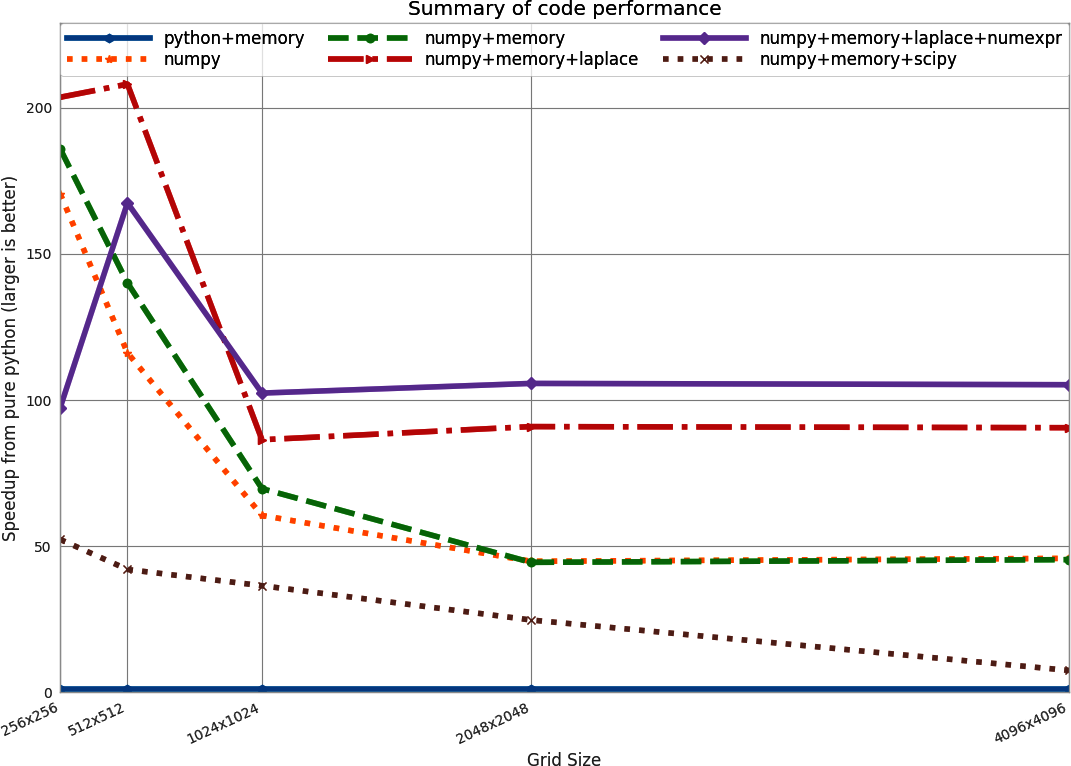

本节中尝试的加速方法总结

另一个重要的教训是使用外部库。Python的易用性和可读性非常好，可以让您快速编写和调试代码。但是，将性能降低到外部库是至关重要的。这些外部库可以非常快，因为它们可以用较低级别的语言编写，但是由于它们与Python接口，所以您仍然可以快速编写使用它们的代码。

最后，我们了解了在进行实验之前对所有事情进行基准测试并形成关于性能的假设的重要性。通过在运行基准测试之前形成一个假设，我们能够形成条件来告诉我们优化是否真的有效。这个改变能加速运行时间吗？它是否减少了分配数量？缓存未命中数是否较低？由于计算机系统的巨大复杂性，优化有时是一门艺术，而对实际发生的事情进行定量的探究会有很大的帮助。

关于优化的最后一点是，必须非常小心地确保您所做的优化可以推广到不同的计算机（您所做的假设和所做的基准测试的结果可能取决于您运行的计算机的体系结构、您所使用的模块是如何编译的等等）。此外，在进行这些优化时，考虑其他开发人员以及更改将如何影响代码的可读性是非常重要的。例如，我们意识到我们在示例中实现的解决方案可能是含糊不清的，所以要小心确保代码被完整地记录和测试，以不仅帮助我们，而且也帮助团队中的其他人。

然而，有时，你的数值算法也需要相当多的数据争论和操作，而不仅仅是明确的数学运算。在这些情况下，熊猫是一个非常流行的解决方案，它有自己的性能特点。我们现在将深入研究熊猫，了解如何更好地使用它来编写高性能的数字代码。

# Pandas

Pandas是科学Python生态系统中用于表格数据的实际数据操作工具。它支持对异构数据类型（称为DataFrames）的类似Excel的表进行轻松操作，并且对时间序列操作具有强大的支持。自2008年以来，公共界面和内部机制都有了很大的发展，在“快速解决问题的方法”的公共论坛上有很多相互矛盾的信息。在本节中，我们将纠正一些关于熊猫常见用例的误解。

我们将回顾Pandas的内部模型，了解如何在数据帧中高效地应用函数，了解为什么重复连接到数据帧是构建结果的糟糕方法，并了解处理字符串的更快方法。

## Pandas的内部模型

Pandas使用内存中的、2D的、类似表格的数据结构如果你想到了Excel表格，你就有了一个好的初始心智模型。最初，Pandas主要关注NumPy的数据类型对象，例如每列的有符号和无符号数字。随着库的发展，它扩展到了NumPy类型之外，现在可以处理Python字符串和扩展类型（包括可为null的Int64对象，注意大写的“I”和IP地址）。

数据帧上的操作适用于一列中的所有单元格（如果使用axis=1参数，则适用于一行中的所有单元格），所有操作都被急切地执行，并且不支持查询计划。对列的操作通常会生成临时的中间数组，这会消耗RAM。一般的建议是，在处理数据帧时，需要一个临时内存使用信封，其使用量最多为当前使用量的三到五倍。通常情况下，Pandas对于10gb以下的数据集工作得很好，前提是您有足够的RAM用于临时结果。

操作可以是单线程的，并且可能受到Python全局解释器锁（GIL）的限制。越来越多地，改进的内部实现允许自动禁用GIL，从而实现并行化操作。我们将在“Parallel Pandas with Dask”中探讨一种与Dask并行的方法。

在幕后，相同数据类型的列由块管理器分组在一起。这种隐藏的机制可以加快对相同数据类型列的行操作。这是许多隐藏的技术细节之一，这些细节使Pandas代码库变得复杂，但却使面向用户的高级操作变得更快。

对单个公共块中的数据子集执行操作通常会生成一个视图，而获取跨不同数据类型块的行切片可能会导致复制，这可能会比较慢。一个结果是，虽然数值列直接引用其NumPy数据，但字符串列引用Python字符串列表，并且这些单独的字符串分散在内存中，这可能导致数值和字符串操作的速度出现意外差异。
在幕后，Pandas混合使用NumPy数据类型和它自己的扩展数据类型。NumPy的示例包括int8（1字节）、int64（8字节，注意小写字母“i”）、float16（2字节）、float64（8字节）和bool（1字节）。Pandas提供的其他类型包括categorical和datetimetz。从外观上看，它们的工作方式类似，但在Pandas代码库的幕后，它们会导致大量类型特定的Pandas代码和重复。

使用NumPy的数据类型的一个副作用是，虽然float有一个NaN（缺少值）状态，但int和bool对象的情况并非如此。如果在Pandas中的int或bool序列中引入NaN值，则序列将升级为float。将int类型提升为float可能会降低用相同位表示的数字精度，最小的float是float16，它占用的字节数是bool的两倍。

可为空的Int64（注意大写的“I”）在版本0.24中作为Pandas中的扩展类型引入。在内部，它使用 NumPy int64和第二个布尔数组作为NaN掩码。Int32和Int8存在等价物。从Pandas版本1.0开始，还有一个等价的可为null的Boolean（dtype Boolean与numpy bool相反，后者不知道NaN）。引入了一个StringDType，它将来可能会提供比标准Python str更高的性能和更少的内存使用，标准Python str存储在objectdtype列中。

## 将函数应用于多行数据

将函数应用于Pandas中的数据行是非常常见的。有多种方法可供选择，而使用循环的惯用Python方法通常是最慢的。我们将通过一个基于现实世界挑战的示例，展示解决此问题的不同方法，并以速度和可维护性之间的权衡作为结束。

普通最小二乘法（OLS）是数据科学中一种简单易行的方法，用于拟合数据线。给出了一些数据，求出了m*x+c方程的斜率和截距。当试图理解数据的趋势时，这可能非常有用：它通常是在增加，还是在减少？

我们工作中使用它的一个例子是一个电信公司的研究项目，我们希望分析一组潜在的用户行为信号（例如，营销活动、人口统计和地理行为）。这家公司有一个人每天花在手机上的小时数，它的问题是：这个人是在增加还是减少手机的使用量，以及这种情况如何随着时间的推移而改变？

解决这个问题的一种方法是，将公司拥有数百万用户的大型数据集在多年的数据中分割成更小的数据窗口（例如，每个窗口代表数据年中的14天）。对于每个窗口，我们通过OLS对用户的使用进行建模，并记录他们是增加还是减少使用。

最后，我们为每个用户提供了一个序列，显示在给定的14天时间内，他们的使用量通常是增加还是减少。然而，要达到这一点，我们必须运行OLS大量的次数！

对于100万用户和两年的数据，我们可能有730个windows，12个，从而730000000个OLS调用！为了实际解决这个问题，我们的OLS实现应该得到很好的调整。
为了了解各种OLS实现的性能，我们将生成一些较小但具有代表性的合成数据，以便很好地指示在较大的数据集上预期会发生什么。我们将为100000行生成数据，每行表示一个合成用户，每行包含14列表示14天的“每天使用的小时数”，作为一个连续变量。

我们将从泊松分布（lambda==60作为分钟）中得出，然后除以60，得到模拟的使用小时数作为连续值。随机数据的真实性质对这个实验并不重要；使用最小值为0的分布是很方便的，因为这代表了现实世界中的最小值。请看示例：

我们看到三行14天的合成数据。

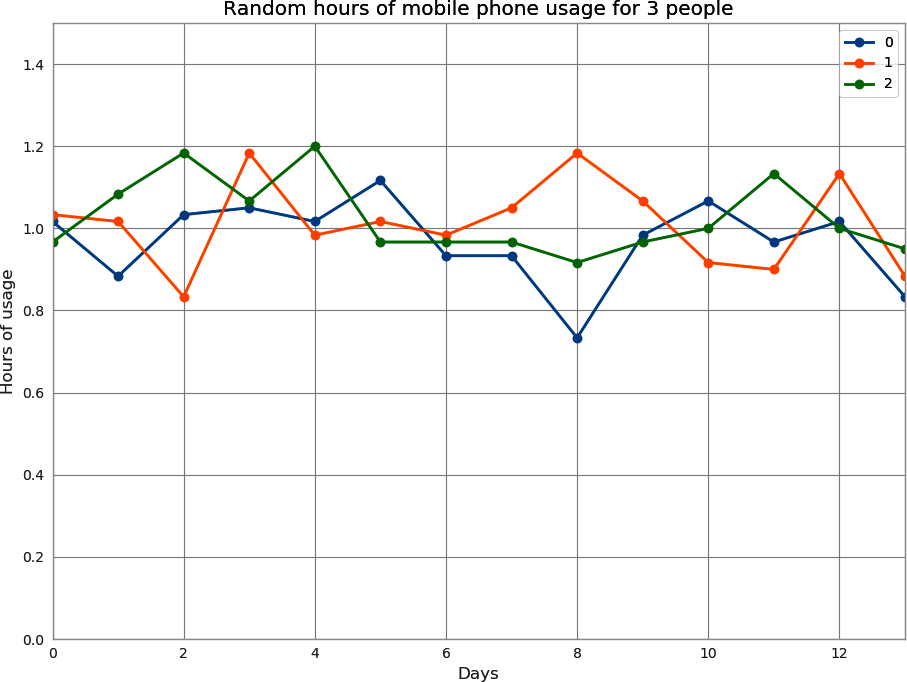

生成100000行数据的好处是，仅通过随机变化，某些行将显示“计数增加”，而某些行将显示“计数减少”。请注意，在我们的合成数据中，这背后没有信号，因为这些点是独立绘制的；仅仅因为我们生成了许多行数据，我们将看到我们计算的直线的最终斜率的变化。

这很方便，因为我们可以确定“最增长”和“最下降”的线，并绘制它们作为验证，我们正在确定我们希望在现实问题上输出的信号类型。图显示了我们的两条随机记录道的最大和最小斜率（m）。

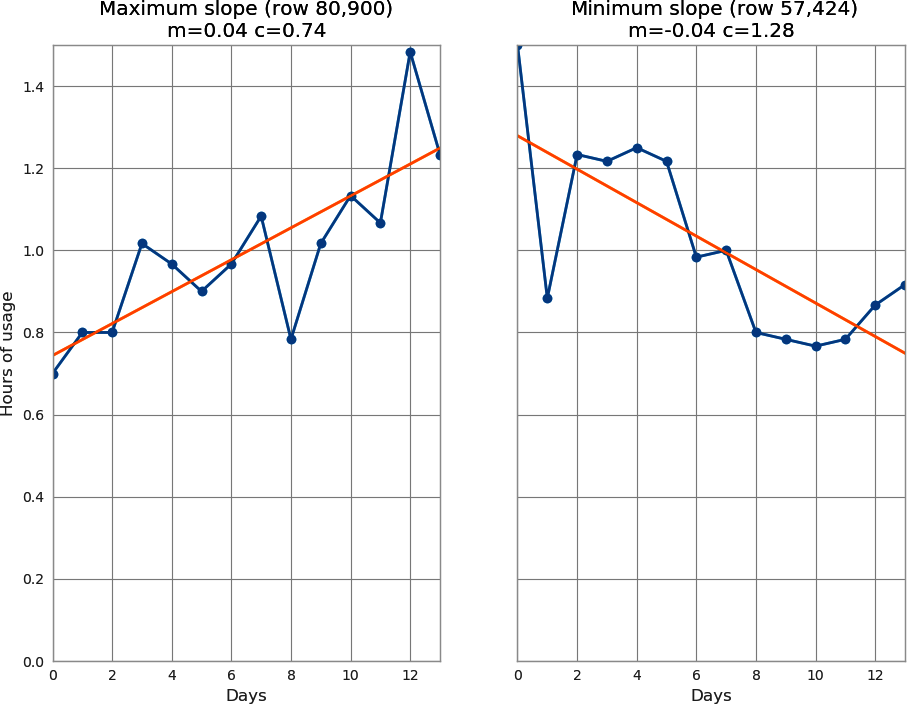

在我们随机生成的数据集中，“最多增加”和“最多减少”的使用

我们将从scikit-learn的线性回归估计器开始计算每个m。虽然这种方法是正确的，但我们将在下一节中看到，与另一种方法相比，它会带来令人惊讶的开销。

##### 我们应该使用哪种OLS实现？

例子展示了我们想尝试的三种实现。我们将评估scikit learn实现与使用NumPy的直接线性代数实现。这两种方法最终执行相同的工作，并在给定增加的x范围（值为[0，1，…，13]）的情况下，从每一行计算目标数据的斜率（m）和截距（c）。

scikit-learn将是许多机器学习实践者的默认选择，而来自其他学科的人可能更喜欢线性代数解决方案。

例:用NumPy和scikit-learn求解普通最小二乘

In [16]:
def ols_sklearn(row):
    """Solve OLS using scikit-learn's LinearRegression"""
    est = LinearRegression()
    X = np.arange(row.shape[0]).reshape(-1, 1) # shape (14, 1)
    # note that the intercept is built inside LinearRegression
    est.fit(X, row.values)
    m = est.coef_[0] # note c is in est.intercept_
    return m

def ols_lstsq(row):
    """Solve OLS using numpy.linalg.lstsq"""
    # build X values for [0, 13]
    X = np.arange(row.shape[0]) # shape (14,)
    ones = np.ones(row.shape[0]) # constant used to build intercept
    A = np.vstack((X, ones)).T # shape(14, 2)
    # lstsq returns the coefficient and intercept as the first result
    # followed by the residuals and other items
    m, c = np.linalg.lstsq(A, row.values, rcond=-1)[0]
    return m

def ols_lstsq_raw(row):
    """Variant of `ols_lstsq` where row is a numpy array (not a Series)"""
    X = np.arange(row.shape[0])
    ones = np.ones(row.shape[0])
    A = np.vstack((X, ones)).T
    m, c = np.linalg.lstsq(A, row, rcond=-1)[0]
    return m

令人惊讶的是，如果我们用timeit模块调用ols_sklearn 10000次，我们发现执行至少需要0.483微秒，而对相同数据的ols_lstsq则需要0.182微秒。流行的scikit学习解决方案比简洁的NumPy变体要花两倍多的时间！

基于“使用line_profiler逐行测量”中的评测，我们可以使用对象接口（而不是命令行或Jupyter魔术接口）来了解sciket learn实现较慢的原因。在示例中，我们告诉LineProfiler评测est.fit（这是我们的LinearRegression估计器上的sciket learn-fit方法），然后基于之前使用的数据帧调用run。
我们看到了一些惊喜。fit的最后一行调用的linalg.lstsq与我们在ols_lstsq中调用的是同一个linalg.lstsq，那么还有什么会导致我们的减速呢？LineProfiler揭示sciketlearn正在调用另外两种昂贵的方法，即check_x_y和预处理数据。

这两种方法都是为了帮助我们避免犯错误。事实上，您的作者Ian已经多次避免了向scikit learn估计器传递不适当的数据，例如形状错误的数组或包含NaN的数组。这种检查的结果是，它需要更多的时间更安全，使事情运行较慢！我们在用开发时间（和理智）和执行时间做交易。

##### 深入了解scikit learn的lineargression.fit调用

在幕后，这两种方法正在执行各种检查，包括：
- 检查适当的稀疏NumPy数组（即使在本例中我们使用密集数组）
- 将输入数组的平均值偏移为0，以在比我们使用的更宽的数据范围内提高数值稳定性
- 检查我们是否提供了一个2dx阵列
- 检查我们没有提供NaN或Inf值
- 检查是否提供了非空的数据数组

一般来说，我们更喜欢启用所有这些检查，它们可以帮助我们避免痛苦的调试会话，这会降低开发人员的工作效率。如果我们知道我们的数据是我们选择的算法的正确形式，这些检查将增加一个惩罚。这些方法的安全性何时会影响到你的整体生产力，这取决于你自己。

作为一般规则，请使用更安全的实现（在本例中是sciket learn），除非您确信数据的形式正确，并且正在优化性能。我们追求的是更高的性能，所以我们将继续使用ols_lstsq方法。

##### 将LSTSQ应用于我们的数据行

我们将从许多来自其他编程语言的Python开发人员可能尝试的方法开始。这不是惯用的Python，对熊猫来说也不常见，甚至效率也不高。它的优点是很容易理解。在示例中，我们将迭代数据帧的索引，从第0行到第99999行；在每次迭代中，我们将使用iloc检索一行，然后计算该行的OLS。

以下每种方法都有相同的计算方法，不同的是我们对行的迭代方式。该方法耗时18.6秒；在我们正在评估的选项中，这是迄今为止最慢的方法（3倍）。
在幕后，每次取消引用都是非常昂贵的，iloc使用一个新的row_idx来获取行，然后将其转换为一个新的Series对象，该对象被返回并分配给row。

我们最糟糕的实现是使用iloc一次计算和获取一行:

接下来，我们将采用更惯用的Python方法：在示例中，我们使用iterrows对行进行迭代，这类似于使用for循环对Python iterable（例如，列表或集合）进行迭代。这种方法看起来很合理，而且速度稍快，需要12.4秒。

这是更有效的，因为我们不必做那么多的查找ItErrors可以沿着行走，而不必做大量的顺序查找。在循环的每次迭代中，行仍然被创建为一个新的序列。

iterrows提供了更高效和“类似Python”的行操作:

下面例子跳过了大量的Pandas机制，因此避免了大量的开销。apply直接向函数ols_lstsq传递一行新的数据（同样，在幕后为每行构造一个新的序列），而不创建Python中间引用。这花费了6.8秒，这是一个显著的改进，而且代码更加紧凑易读！

应用 apply 函数应用程序:

下面示例中的最后一个变体将同一个apply调用与另一个 raw=True 参数一起使用。使用 raw=Tru e停止创建中间序列对象。因为我们没有Series对象，所以必须使用第三个OLS函数 ols_lstsq_raw ；此变体可以直接访问底层NumPy数组。

通过避免创建和取消对中间序列对象的引用，我们将执行时间再缩短一点，减少到5.3秒。

避免使用raw=True创建中间序列:

raw=True 的使用为我们提供了使用Numba（“Numba to compile NumPy for Pandas”）或使用Cython进行编译的选项，因为它消除了编译当前不支持的Pandas层的复杂性。

我们将在表中总结执行时间在一个由14列模拟数据组成的单个窗口上显示100000行数据。新用户经常使用iloc和iterrows（或类似的itertuples），如果apply是首选。

通过执行我们的分析，并考虑到我们可能需要对1000000行（最多730个数据窗口）执行OLS，我们可以看到，将iloc与 ols_sklearn 相结合的第一种简单方法可能需要10（我们更大的数据集因子）`*730*18秒*2`（我们相对于 ols_lstsq 的减速因子）==73小时。

如果我们使用ols_lstsq_raw和我们最快的方法，同样的计算可能需要`10*730*5.3秒==10小时`。对于表示一组类似操作的任务来说，这是一个显著的节省。如果我们在多核上编译和运行，我们将看到更快的解决方案。

将lstsq与各种行方法结合使用的成本:

<table id="pandas_table_iteration_costs">
<thead>
<tr>
<th>Method</th>
<th>Time in seconds</th>
</tr>
</thead>
<tbody>
<tr>
<td><p>iloc</p></td>
<td><p>18.6</p></td>
</tr>
<tr>
<td><p>iterrows</p></td>
<td><p>12.4</p></td>
</tr>
<tr>
<td><p>apply</p></td>
<td><p>6.8</p></td>
</tr>
<tr>
<td><p>apply raw=True</p></td>
<td><p>5.3</p></td>
</tr>
</tbody>
</table>

早些时候，我们发现sciket learn方法通过使用安全的检查网络覆盖数据，给执行时间增加了大量开销。我们可以删除这个安全网，但可能会花费开发人员调试时间。您的作者强烈建议您考虑向代码中添加单元测试，以验证是否使用了一个众所周知且经过良好调试的方法来测试您确定的任何优化方法。如果您添加了一个单元测试来比较scikit learn LinearRegression方法和ols_lstsq方法，您将给您自己和其他同事一个未来的提示，告诉他们为什么您开发了一个不太明显的解决方案来解决看似标准的问题。

通过实验，您还可以得出结论：经过大量测试的sciket learn方法对于您的应用程序来说已经足够快了，并且您可以更轻松地使用其他开发人员熟知的库。这可能是一个非常明智的结论。

在后面的“使用Dask并行Pandas”中，我们将通过使用Dask和Swifter将数据划分为行组来研究跨多个核运行Pandas操作。在“Numba to Compile NumPy for Pandas”中，我们将研究编译apply的raw=True变量，以实现一个数量级的加速。编译和并行化可以结合在一起，实现真正显著的最终加速，将我们预期的运行时间从大约10小时减少到30分钟。

## 从部分结果构建数据帧和序列，而不是串联

你可能想知道为什么我们建立了一个部分结果的列表，然后我们将其转化为一个系列，而不是在我们前进的过程中逐步建立这个系列。我们以前的方法需要建立一个列表（有内存开销），然后为序列建立第二个结构，在内存中给我们两个对象。当使用Pandas和NumPy,这给我们带来了另一个常见的错误。

一般来说，应该避免重复调用Pandas中的concat（以及NumPy中的等效连接）。在下面案，但是没有中间ms列表。此解决方案需要56秒，而使用列表的解决方案需要18.6秒！

连接每个结果会产生很大的开销避免这种情况！

## 有不止一种（可能更快）的方法来完成一项工作

由于Pandas的进化，通常有两种方法来解决相同的任务，其中一些方法比其他方法产生更多的开销。让我们使用OLS DataFrame并将一列转换为一个字符串；然后我们将计时一些字符串操作。对于包含名称、产品标识符或代码的基于字符串的列，通常需要对数据进行预处理以将其转换为我们可以分析的内容。

假设我们需要从其中一列的数字中找到数字9的位置（如果存在的话）。虽然这个操作没有真正的目的，但它非常类似于检查标识符序列中是否有带代码的符号，或者检查名称中是否有敬语。通常对于这些操作，我们会使用strip来删除无关的空白，lower和replace来规范化字符串，并找到感兴趣的内容。

在示例中，我们首先构建一个名为0_as_str的新序列，它是将随机数转换为可打印字符串形式的第0个序列。然后我们将运行两种不同的字符串操作代码，这两种代码都将删除前导数字和小数点，然后使用Python的find查找前9个（如果存在），否则返回-1。

str系列操作与应用于字符串处理：

In [ ]:
df['0_as_str'] = df[0].apply(lambda v: str(v))

In [ ]:
def find_9(s):
    """Return -1 if '9' not found else its location at position >= 0"""
    return s.split('.')[1].find('9')

In [ ]:
df['0_as_str'].str.split('.', expand=True)[1].str.find('9')

In [ ]:
%timeit df['0_as_str'].str.split('.', expand=True)[1].str.find('9')

In [ ]:
%timeit df['0_as_str'].apply(find_9)

单行方法使用Pandas的str操作来访问Python的字符串方法。对于split，我们将返回的结果展开为两列（第一列包含前导数字，第二列包含小数点后的所有内容），然后选择第1列。然后我们应用find来定位数字9。第二种方法使用apply和find_函数，该函数读起来像一个常规的Python字符串处理函数。

我们可以用%timeit来检查运行时，这表明有一个3.5× 两种方法之间的速度差异，即使它们产生相同的结果！在前一种单线情况下，Pandas需要生成多个新的中间序列对象，这增加了开销；在find_9中，所有的字符串处理工作一次只进行一行，而不创建新的中间对象。

apply方法的进一步好处是，我们可以并行化这个操作（请参阅“Parallel Pandas with Dask”以获取Dask和Swifter的示例），并且我们可以编写一个单元测试，简洁地确认find_执行的操作，这将有助于可读性和维护。

## Pandas 未来

安装可选的依赖项numexpr和瓶颈，以获得额外的性能改进。默认情况下不会安装这些，并且不会告诉您它们是否丢失。在代码库中很少使用瓶颈；然而，当您使用exec时，numexpr在某些情况下会提供显著的加速。您可以使用 import bottleneck 和 import numexpr 测试环境中两者的存在。

不要把代码写得太简洁；记住让你的代码易于阅读和调试，以帮助你未来的自我。虽然“方法链接”样式是受支持的，但是您的作者应该注意不要按顺序链接太多的操作行。在调试时，通常很难找出哪一行有问题，然后必须将这些行分开，最好只将几个操作链接在一起，以简化维护。

避免做过多的工作：如果可能的话，最好在计算剩余行之前过滤数据，而不是在计算之后过滤。一般来说，为了获得高性能，我们要求机器尽可能少地进行计算；如果你能过滤掉或屏蔽掉你的部分数据，你可能会赢。如果您使用的是来自SQL源的数据，后来又加入Pandas或在Pandas中进行过滤，那么您可能希望首先尝试在SQL级别进行过滤，以避免将过多的数据拉入Pandas。如果您正在调查数据质量，您可能不希望一开始就这样做，因为对您拥有的各种数据类型有一个简化的视图可能更有益。

在数据帧发展过程中检查它们的模式；使用像bulwark这样的工具，您可以在运行时保证您的模式得到满足，并且可以在查看代码时直观地确认您的期望得到满足。在生成新结果时不断重命名列，以便数据框的内容对您有意义；有时groupby和其他操作会给你一些愚蠢的默认名称，这以后可能会让人困惑。使用.Drop（）删除不再需要的列以减少膨胀和内存使用。

对于包含低基数字符串的大型序列（例如“yes”和“no”，或“type_a”、“type_b”和“type_c”），请尝试将序列转换为具有df['Series_of_strings'].astype（'Category'）的Category数据类型；您可能会发现像value\u counts和groupby这样的操作运行得更快，而且这个系列可能会消耗更少的内存。

类似地，您可能希望将8字节float64和int64列转换为更小的数据类型，如果您需要更小的范围来进一步保存RAM，则可能是2字节float16或1字节int8。
当您演进数据帧并生成新的副本时，请记住，您可以使用del关键字删除早期引用，并从内存中清除它们（如果它们太大并且浪费空间）。也可以使用Pandas drop方法删除未使用的列。

如果在准备处理数据时操作大型数据帧，则可以在函数或单独的脚本中执行一次这些操作，然后使用topickle将准备好的版本持久化到磁盘。您可以随后处理准备好的数据帧，而无需每次都对其进行处理。

避免使用inplace=True运算符，计划随着时间的推移从库中删除就地操作。

最后，总是向任何处理代码添加单元测试，因为它将很快变得更复杂，更难调试。提前开发测试可以保证代码满足您的期望，并帮助您避免以后出现愚蠢的错误，这会耗费开发人员调试时间。

现有的让熊猫跑得更快的工具包括Modin和以GPU为核心的cuDF。Modin和cuDF采用不同的方法来并行化一个类似于DataFrame的对象上的公共数据操作。
我们还想向新的瓦克斯图书馆致敬。Vaex设计用于处理超过RAM的非常大的数据集，通过使用延迟评估，同时保留与Pandas相似的接口。此外，Vaex还提供了一系列内置的可视化功能。一个设计目标是使用尽可能多的cpu，尽可能免费提供并行性。

Vaex擅长于更大的数据集和字符串繁重的操作；作者已经改写了许多字符串操作以避免标准Python函数，而使用C++中更快的VAX实现。请注意，Vaex不能保证以与Pandas相同的方式工作，因此，如果您同时尝试Pandas和Vaex处理相同的数据，那么您可能会发现具有不同行为的边缘情况，使用单元测试返回代码以获得信心。

# 练习：利用 pandas 高效存储数据

在大数据处理中，我们将使用许多不同的数据集，为了提高效率和性能，有必要对主要格式进行比较。具体来说，我们将比较以下内容：
- CSV：逗号分隔的标准文本文件格式。
- HDF5：分层数据格式，最初由美国国家超级计算应用中心开发。它是一种快速且可扩展的数值数据存储格式，可在pandas中使用PyTables库。
- Parquet：Apache Hadoop 生态系统的一部分，是一种二进制、列式存储格式，提供了高效的数据压缩和编码，由Cloudera和Twitter开发。pandas 可以通过pyarro库获得，这个库由pandas 的原作者Wes McKinney领导。

使用可配置为包含数字或文本数据（或两者）的测试数据帧来比较前面的库的性能。对于HDF5库，我们测试固定格式和表格式。表格格式允许查询，并且可以附加到。

下面的图表说明了100000行的读写性能，其中有1000列随机浮点，1000列为随机10个字符字符串，或者只有2000个浮点列（按日志规模）：

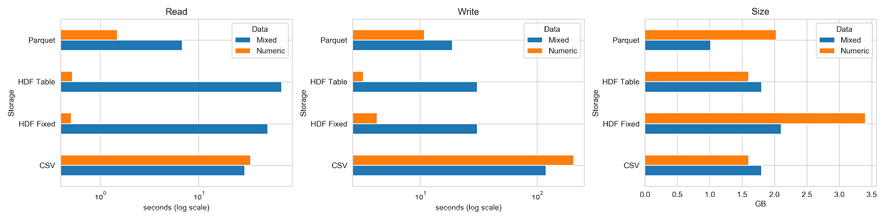

左面板显示，对于纯数字数据，HDF5格式性能最好，而表格式也与CSV共享最小的内存占用，为1.6GB。固定格式使用两倍的空间，而Parquet格式使用2GB。

对于数字和文本数据的混合，Parquet是读写操作的最佳选择。与CSV相比，HDF5在read方面有优势，但在write中则较慢，因为它会对文本数据进行pickle处理。

下面演示如何使用%%timeit cell magic配置、测试和收集计时，同时演示了使用这些存储格式所需的相关pandas命令的用法。

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import string

In [2]:
sns.set_style('whitegrid')

In [3]:
results = {}

## 生成测试数据

测试 `DataFrame` ，可配置为包含数字或文本数据，或两者都包含。对于HDF5库，我们测试固定格式和表格式。

In [4]:
def generate_test_data(nrows=10000, numerical_cols=2000, text_cols=0, text_length=10):
    ncols = numerical_cols + text_cols
    s = "".join([random.choice(string.ascii_letters)
                 for _ in range(text_length)])
    data = pd.concat([pd.DataFrame(np.random.random(size=(nrows, numerical_cols))),
                      pd.DataFrame(np.full(shape=(nrows, text_cols), fill_value=s))],
                     axis=1, ignore_index=True)
    data.columns = [str(i) for i in data.columns]
    return data

In [5]:
data_type = 'Mixed'

In [6]:
df = generate_test_data(numerical_cols=1000, text_cols=1000)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 2000 entries, 0 to 1999
dtypes: float64(1000), object(1000)
memory usage: 152.6+ MB


## Parquet

### Size

In [7]:
parquet_file = Path('test.parquet')

In [8]:
df.to_parquet(parquet_file, compression="gzip",engine="fastparquet")
size = parquet_file.stat().st_size

### Read

In [9]:
%%timeit -o
df = pd.read_parquet(parquet_file)

3.44 s ± 75.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


<TimeitResult : 3.44 s ± 75.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)>

In [10]:
read = _

In [11]:
parquet_file.unlink()

### Write

In [12]:
%%timeit -o
df.to_parquet(parquet_file, compression="gzip")
parquet_file.unlink()

12.8 s ± 202 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


<TimeitResult : 12.8 s ± 202 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)>

In [13]:
write = _

### Results

In [14]:
results['Parquet'] = {'read': np.mean(read.all_runs), 'write': np.mean(write.all_runs), 'size': size}

## HDF5

In [15]:
test_store = Path('index.hdf5')

### Fixed Format

#### Size

In [16]:
with pd.HDFStore(test_store) as store:
    store.put('file', df)
size = test_store.stat().st_size

HDF5ExtError: HDF5 error back trace

  File "D:\pytables_hdf5\CMake-hdf5-1.10.5\hdf5-1.10.5\src\H5F.c", line 509, in H5Fopen
    unable to open file
  File "D:\pytables_hdf5\CMake-hdf5-1.10.5\hdf5-1.10.5\src\H5Fint.c", line 1652, in H5F_open
    unable to read superblock
  File "D:\pytables_hdf5\CMake-hdf5-1.10.5\hdf5-1.10.5\src\H5Fsuper.c", line 623, in H5F__super_read
    truncated file: eof = 96, sblock->base_addr = 0, stored_eof = 2048

End of HDF5 error back trace

Unable to open/create file 'index.hdf5'

#### Read

In [ ]:
%%timeit -o
with pd.HDFStore(test_store) as store:
    store.get('file')

In [ ]:
read = _

In [ ]:
test_store.unlink()

#### Write

In [ ]:
%%timeit -o
with pd.HDFStore(test_store) as store:
    store.put('file', df)
test_store.unlink()

In [ ]:
write = _

#### Results

In [ ]:
results['HDF Fixed'] = {'read': np.mean(read.all_runs), 'write': np.mean(write.all_runs), 'size': size}

### Table Format

#### Size

In [ ]:
with pd.HDFStore(test_store) as store:
    store.append('file', df, format='t')
size = test_store.stat().st_size    

#### Read

In [ ]:
%%timeit -o
with pd.HDFStore(test_store) as store:
    df = store.get('file')

In [ ]:
read = _

In [ ]:
test_store.unlink()

#### Write

请注意，表格格式中的 `write`不能处理文本数据。

In [ ]:
%%timeit -o
with pd.HDFStore(test_store) as store:
    store.append('file', df, format='t')
test_store.unlink()    

In [ ]:
write = _

#### Results

In [ ]:
results['HDF Table'] = {'read': np.mean(read.all_runs), 'write': np.mean(write.all_runs), 'size': size}

### Table Select

#### Size

In [ ]:
with pd.HDFStore(test_store) as store:
    store.append('file', df, format='t', data_columns=['company', 'form'])
size = test_store.stat().st_size 

#### Read

In [ ]:
company = 'APPLE INC'

In [ ]:
%%timeit
with pd.HDFStore(test_store) as store:
    s = store.get('file')

In [ ]:
read = _

In [ ]:
test_store.unlink()

#### Write

In [ ]:
%%timeit
with pd.HDFStore(test_store) as store:
    store.append('file', df, format='t', data_columns=['company', 'form'])
test_store.unlink() 

In [ ]:
write = _

#### Results

In [ ]:
results['HDF Select'] = {'read': np.mean(read.all_runs), 'write': np.mean(write.all_runs), 'size': size}

## CSV

In [ ]:
test_csv = Path('test.csv')

### Size

In [ ]:
df.to_csv(test_csv)
test_csv.stat().st_size

### Read

In [ ]:
%%timeit -o
df = pd.read_csv(test_csv)

In [ ]:
read = _

In [ ]:
test_csv.unlink()  

### Write

In [ ]:
%%timeit -o
df.to_csv(test_csv)
test_csv.unlink()

In [ ]:
write = _

### Results

In [ ]:
results['CSV'] = {'read': np.mean(read.all_runs), 'write': np.mean(write.all_runs), 'size': size}

In [ ]:
pd.DataFrame(results).to_csv(f'{data_type}.csv')

## Store Results

In [ ]:
df = (pd.read_csv('Mixed.csv', index_col=0)
      .rename(columns=str.capitalize))
df.head()

In [ ]:
df = df.T

In [ ]:
df = df.rename(columns=str.capitalize)

In [ ]:
df.head()

In [ ]:
df.index.name='Storage'
df.Size /= 1e9

In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(16, 4))
for i, op in enumerate(['Read', 'Write', 'Size']):
    flag= op in ['Read', 'Write']
    df.loc[:, op].plot.barh(title=op, ax=axes[i], logx=flag)
    if flag:
        axes[i].set_xlabel('seconds (log scale)')
    else:
        axes[i].set_xlabel('GB')
fig.tight_layout()
fig.savefig('storage', dpi=300);

#  小结

在下一节中，我们将讨论如何创建自己的外部模块，这些模块可以进行微调，以更高效地解决特定问题。这使我们能够遵循快速原型的方法，让我们的程序首先用慢代码解决问题，然后识别出慢的元素，最后找到让这些元素更快的方法。通过经常分析代码并尝试只优化我们知道的代码部分是缓慢的，我们可以节省自己的时间，同时仍然使我们的程序尽可能快地运行。